In [105]:
import tifffile
import pandas as pd
import numpy as np
from skimage.measure import regionprops
import warnings
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.decomposition import PCA
import os
from collections import OrderedDict

In [106]:
def rotate(mat, angle_deg, center=None, dims=(0, 1)):
    """
    Rotate points in the plane defined by dims by angle_deg degrees.

    Parameters
    ----------
    mat : (n, d) array
        Input coordinates, e.g. PCA coordinates.
    angle_deg : float
        Rotation angle in degrees. Positive = counterclockwise.
    center : array-like of shape (2,), optional
        Center of rotation in the selected dims.
        If None, uses the centroid in those dims.
    dims : tuple of int
        Which two columns to rotate. Default: (0, 1).

    Returns
    -------
    out : (n, d) array
        Rotated copy of mat.
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    Y = out[:, dims]

    if center is None:
        center = Y.mean(axis=0)
    else:
        center = np.asarray(center, dtype=float)

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    out[:, dims] = (Y - center) @ R.T + center
    return out


def standardize(mat, dims=(0, 1)):
    """
    Scale each selected axis independently to span [-1, 1].

    Parameters
    ----------
    mat : (n, d) array
    dims : tuple of int
        Which columns to rescale.

    Returns
    -------
    out : (n, d) array
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    for d in dims:
        x = out[:, d]
        xmin, xmax = x.min(), x.max()
        if np.isclose(xmax, xmin):
            out[:, d] = 0.0
        else:
            out[:, d] = 2 * (x - xmin) / (xmax - xmin) - 1

    return out

In [107]:
roi = tifffile.imread('data/Vsx1_3_D_Kn_Ey_cp_masks.tif')
signal = tifffile.imread('data/Vsx1_3_D_Kn_Ey.tif')

In [108]:
if signal.ndim > 2:
  signal = np.moveaxis(signal, 1, -1)

In [109]:
stats = regionprops(roi, signal)

In [110]:
out = {'label': [], 'centroid_x': [], 'centroid_y': [], 'centroid_z': [], 'area': [], 'aspherity': []}

if signal.ndim == 4:
    for i in range(signal.shape[3]):
        out[f'int_{i}'] = []
else:
    out['int'] = []

for i in stats:
    out['label'].append(i.label)
    out['centroid_x'].append(i.centroid[0])
    out['centroid_y'].append(i.centroid[1])
    out['centroid_z'].append(i.centroid[2])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out['area'].append(i.area_convex)
        
    if signal.ndim == 3:
        out['int'].append(i.intensity_mean)
    else:
        for j in range(signal.shape[3]):
            out[f'int_{j}'].append(i.intensity_mean[j])

    out['aspherity'].append(i.axis_major_length/i.equivalent_diameter_area)

outdf = pd.DataFrame(out)

In [111]:
pca = PCA(n_components=3, svd_solver='auto')
pcaobj = pca.fit_transform(outdf[['centroid_x', 'centroid_y', 'centroid_z']].to_numpy())

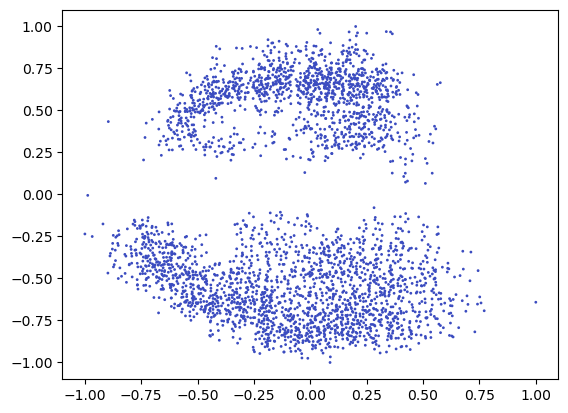

In [114]:
thres = 22500
rot = 90
pcamat2 = standardize(rotate(pcaobj, rot))

_ = plt.scatter(
  pcamat2[:, 0], pcamat2[:, 1], s = 1,
  c=[outdf['int_0'][i] > thres for i in range(outdf.shape[0])],
  cmap='coolwarm'
)

In [115]:
kn_thres = 30000
ey_thres = 25000
kn_ey = [outdf['int_1'][i] > kn_thres and outdf['int_2'][i] > ey_thres for i in range(outdf.shape[0])]
outdf = outdf[kn_ey].reset_index(drop=True)
pcamat2 = pcamat2[kn_ey]

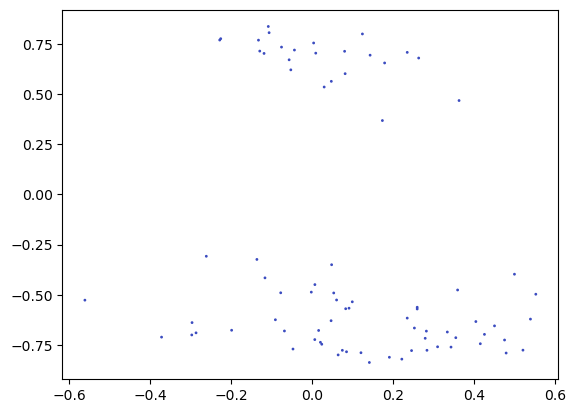

In [116]:
_ = plt.scatter(
  pcamat2[:, 0], pcamat2[:, 1], s = 1,
  c=[outdf['int_0'][i] > thres for i in range(outdf.shape[0])],
  cmap='coolwarm'
)

In [117]:
sname = 'Vsx_3'
outdf['sample'] = sname
outdf['x_std'] = pcamat2[:, 0]
outdf['y_std'] = pcamat2[:, 1]
outdf['z_std'] = pcamat2[:, 2]
outdf['rotation'] = rot
outdf['D_threshold'] = thres
outdf['kn_threshold'] = kn_thres
outdf['ey_threshold'] = ey_thres

In [118]:
outdf.to_csv(f'result/{sname}_preprocessed.csv', index=False)

sample_metadata = OrderedDict([
  ('LacZ_1', {
    'rotation': -100,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/LacZ_1_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/LacZ_1_D_Kn_Ey.tif',
    'condition': 'LacZ OE'
  }),
  ('LacZ_2', {
    'rotation': 80,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/LacZ_2_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/LacZ_2_D_Kn_Ey.tif',
    'condition': 'LacZ OE'
  }),
  ('LacZ_3', {
    'rotation': -80,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/LacZ_3_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/LacZ_3_D_Kn_Ey.tif',
    'condition': 'LacZ OE'
  }),
  ('Vsx_1', {
    'rotation': 130,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/Vsx_1_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/Vsx_1_D_Kn_Ey.tif',
    'condition': 'Vsx OE'
  }),
  ('Vsx_2', {
    'rotation': 80,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/Vsx_2_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/Vsx_2_D_Kn_Ey.tif',
    'condition': 'Vsx OE'
  }),
  ('Vsx_3', {
    'rotation': 90,
    'D_thres': 22500,
    'kn_thres': 30000,
    'ey_thres': 25000,
    'roi_path': 'data/Vsx_3_D_Kn_Ey_cp_masks.tif',
    'signal_path': 'data/Vsx_3_D_Kn_Ey.tif',
    'condition': 'Vsx OE'
  })])